# IVF Pregnancy Prediction Pipeline

## Overview
- EDA 기반 Feature Engineering
- Data Leakage 방지 전처리
- LightGBM + Optuna 하이퍼파라미터 튜닝
- 앙상블 (LightGBM + CatBoost) 학습
- Submission 파일 생성

---

## Pipeline
1. 데이터 로드
2. 전처리
3. Feature Engineering
4. 모델 학습 (Optuna)
5. 예측 및 제출 파일 생성

In [1]:
# =========================
# 설치
# =========================
!pip install koreanize-matplotlib optuna catboost xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [2]:
# ======================================
# 1. import
# ======================================
import pandas as pd
import numpy as np

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import optuna
import joblib

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['axes.unicode_minus'] = False

optuna.logging.set_verbosity(optuna.logging.WARNING)

## 데이터 로드

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print(train.shape, test.shape)
train.head()

(256351, 69) (90067, 68)


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


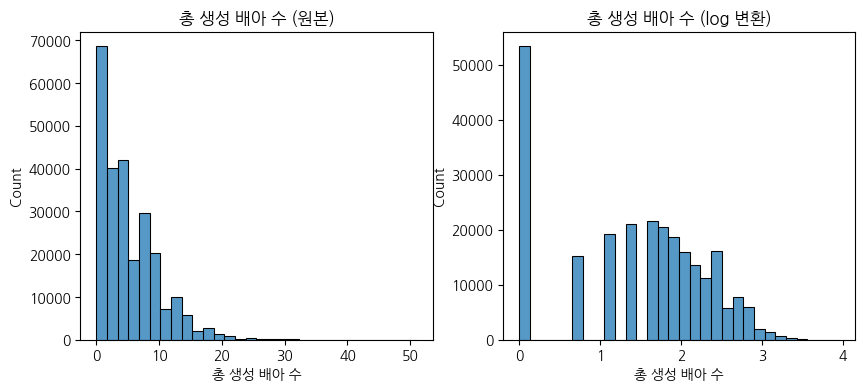

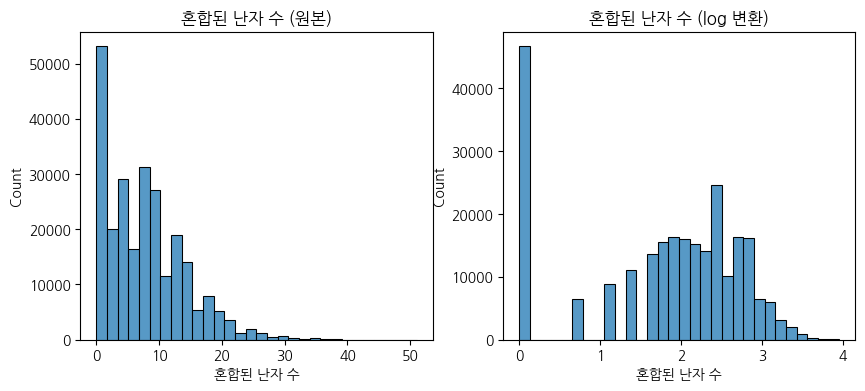

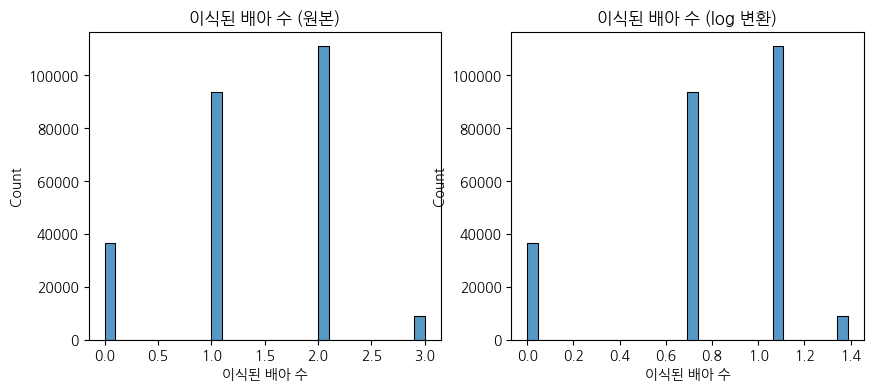

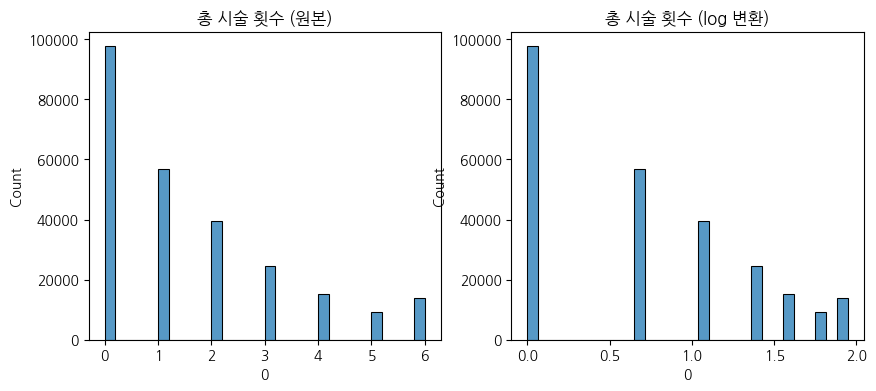

총 시술 횟수
0회       97599
1회       56819
2회       39338
3회       24531
4회       15141
6회 이상    13817
5회        9106
Name: count, dtype: int64
7


In [8]:
# =========================
# EDA - 분포 확인
# =========================

def convert_count(series):
    return (
        series.astype(str)
        .str.extract('(\d+)')[0]
        .astype(float)
    )

num_cols = [
    "총 생성 배아 수",
    "혼합된 난자 수",
    "이식된 배아 수",
    "총 시술 횟수"
]

for col in num_cols:
    if col in train.columns:

        # 핵심: "횟수" 컬럼은 따로 처리
        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(10,4))

        plt.subplot(1,2,1)
        sns.histplot(tmp, bins=30)
        plt.title(f"{col} (원본)")

        plt.subplot(1,2,2)
        sns.histplot(np.log1p(tmp), bins=30)
        plt.title(f"{col} (log 변환)")

        plt.show()

print(train["총 시술 횟수"].value_counts().head(10))
print(train["총 시술 횟수"].nunique())

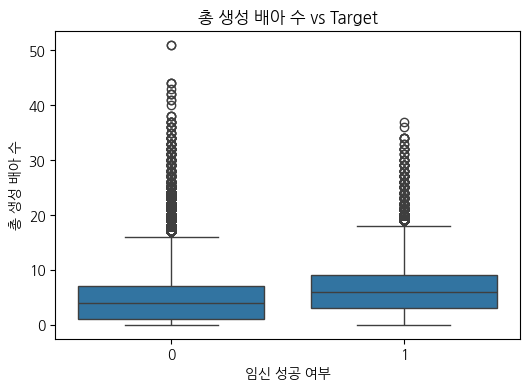

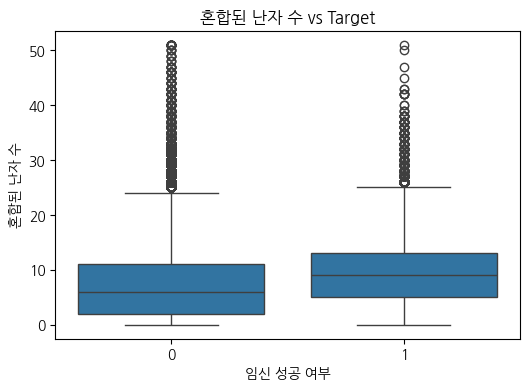

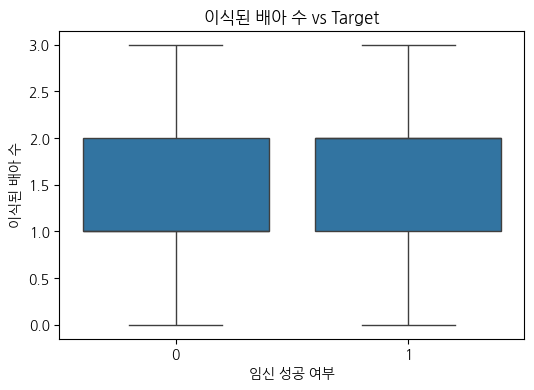

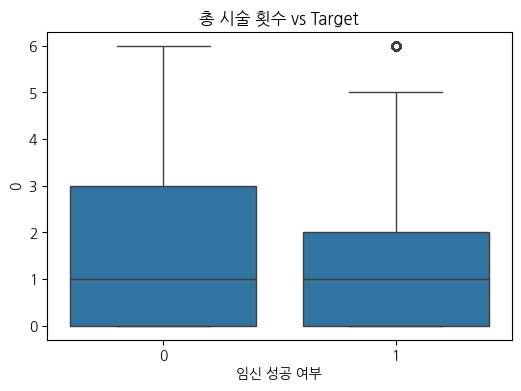

In [9]:
# =========================
# 타겟과 관계 확인
# =========================
for col in num_cols:
    if col in train.columns:

        # 타입 변환
        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(6,4))
        sns.boxplot(x=train[TARGET], y=tmp)
        plt.title(f"{col} vs Target")
        plt.show()

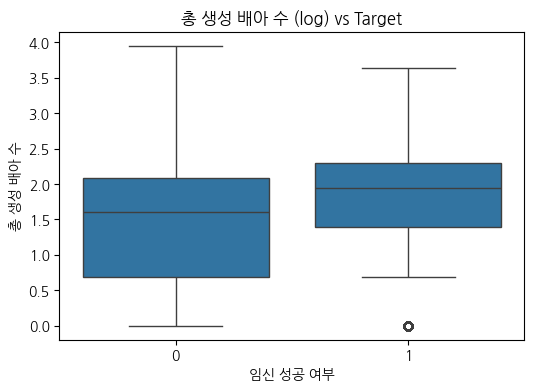

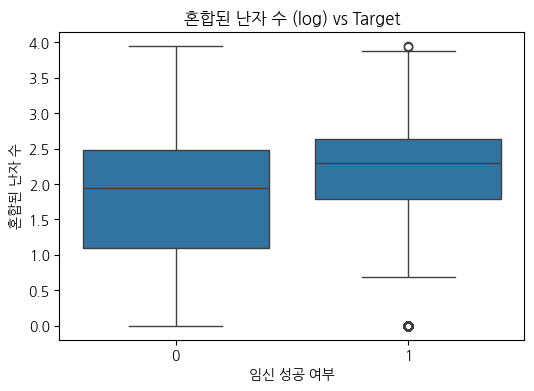

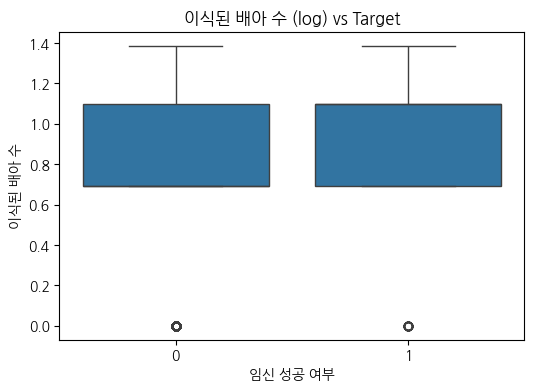

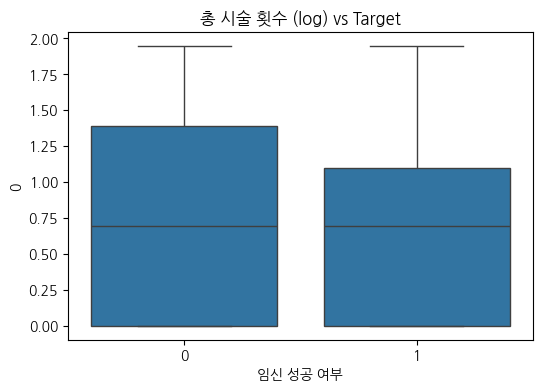

In [10]:
# =========================
# 타겟 vs log 버전 (추천)
# =========================
for col in num_cols:
    if col in train.columns:

        if "횟수" in col:
            tmp = convert_count(train[col])
        else:
            tmp = pd.to_numeric(train[col], errors="coerce")

        plt.figure(figsize=(6,4))
        sns.boxplot(x=train[TARGET], y=np.log1p(tmp))
        plt.title(f"{col} (log) vs Target")
        plt.show()

## 전처리 함수 정의
- Data Leakage 방지
- Train 기준 encoding

In [11]:
# =========================
# 1. 컬럼 제거
# =========================
def drop_columns(df):
    drop_cols = []

    if ID_COL in df.columns:
        drop_cols.append(ID_COL)

    redundant_cols = ["파트너 정자와 혼합된 난자 수"]

    for col in redundant_cols:
        if col in df.columns:
            drop_cols.append(col)

    return df.drop(columns=drop_cols, errors="ignore")


# =========================
# 2. 문자열 → 숫자 변환
# =========================
def convert_str_to_numeric(df):
    age_map = {
        "만18-34세": 26,
        "만35-37세": 36,
        "만38-39세": 38.5,
        "만40-42세": 41,
        "만43-44세": 43.5,
        "만45-50세": 47,
        "알 수 없음": np.nan
    }

    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(age_map)

    # 핵심 추가: "횟수" 컬럼 숫자화
    for col in df.columns:
        if "횟수" in col:
            df[col] = (
                df[col]
                .astype(str)
                .str.extract('(\d+)')[0]
                .astype(float)
            )

    return df


# =========================
# 3. 결측치 처리
# =========================
def handle_missing(df):
    zero_fill_cols = [
        "PGS 시술 여부", "PGD 시술 여부",
        "착상 전 유전 검사 사용 여부",
        "배아 해동 경과일", "난자 해동 경과일"
    ]

    for col in zero_fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    num_cols = df.select_dtypes(include=["number"]).columns
    for col in num_cols:
        if col != TARGET:
            df[col] = df[col].fillna(df[col].median())

    cat_cols = df.select_dtypes(include=["object"]).columns
    for col in cat_cols:
        df[col] = df[col].astype(str).replace(['nan','None'], 'Unknown')

    return df


# =========================
# 4. Feature Engineering
# =========================
def create_features(df):

    num_fix_cols = [
        "총 생성 배아 수", "혼합된 난자 수",
        "이식된 배아 수", "총 임신 횟수", "총 시술 횟수"
    ]

    for col in num_fix_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # =========================
    # log feature 추가
    # =========================
    log_cols = [
        "총 생성 배아 수",
        "혼합된 난자 수",
        "이식된 배아 수"
    ]

    for col in log_cols:
        if col in df.columns:
            df[f"{col}_log"] = np.log1p(df[col])

    # =========================
    # 기존 파생 변수
    # =========================
    df["배아_생성_효율"] = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식_효율"] = df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1)
    df["과거_임신_성공_비율"] = df["총 임신 횟수"] / (df["총 시술 횟수"] + 1)

    df["전체_시술_효율"] = df["배아_생성_효율"] * df["이식_효율"]

    if "시술 당시 나이" in df.columns:
        df["고령_여부"] = (df["시술 당시 나이"] >= 38).astype(int)
        df["나이_이식_상호작용"] = df["시술 당시 나이"] * df["이식된 배아 수"]
        df["난소_반응성_지표"] = df["혼합된 난자 수"] / (df["시술 당시 나이"] + 1)
        df["고령_다배아이식"] = ((df["시술 당시 나이"] >= 38) & (df["이식된 배아 수"] >= 3)).astype(int)

    df["과배란_위험"] = (df["혼합된 난자 수"] > 20).astype(int)
    df["최적_이식_여부"] = df["이식된 배아 수"].between(1, 2).astype(int)

    return df


# =========================
# 5. 인코딩
# =========================
def encode_categorical(train_df, test_df):
    cat_cols = train_df.select_dtypes(include=["object"]).columns

    for col in cat_cols:
        if col == TARGET:
            continue

        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))

        mapping = {k: v for v, k in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(mapping).fillna(-1).astype(int)

    return train_df, test_df


# =========================
# 6. 전체 파이프라인
# =========================
def preprocess(train, test):
    train = drop_columns(train)
    test = drop_columns(test)

    train = convert_str_to_numeric(train)
    test = convert_str_to_numeric(test)

    train = handle_missing(train)
    test = handle_missing(test)

    train = create_features(train)
    test = create_features(test)

    train, test = encode_categorical(train, test)

    return train, test

## 전처리 실행

In [13]:
train_df, test_df = preprocess(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(X.shape, test_df.shape)

(256351, 79) (90067, 79)


## 빠른 모델 비교 (LGBM, XGB, Cat)

In [15]:
# ======================================
# 빠른 모델 비교
# ======================================
def quick_cv(model, name):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # 모델별 분기 처리
        if name == "LGBM":
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )

        elif name == "XGB":
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False
            )

        elif name == "CAT":
            model.fit(
                X_tr, y_tr,
                eval_set=(X_val, y_val),
                verbose=False
            )

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    print(f"{name} CV:", round(np.mean(scores), 5))


# 실행
quick_cv(lgb.LGBMClassifier(n_estimators=500, verbosity=-1), "LGBM")
quick_cv(xgb.XGBClassifier(n_estimators=500, eval_metric="logloss", verbosity=0), "XGB")
quick_cv(CatBoostClassifier(iterations=500, verbose=0), "CAT")

LGBM CV: 0.73851
XGB CV: 0.72199
CAT CV: 0.73863


## Optuna + LightGBM 모델 학습

In [16]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "random_state": 42,
        "n_jobs": -1,

        # 핵심
        "n_estimators": trial.suggest_int("n_estimators", 800, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),

        "num_leaves": trial.suggest_int("num_leaves", 31, 256),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),

        # sampling
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),

        # regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        aucs.append(roc_auc_score(y_val, preds))

    score = np.mean(aucs)

    if trial.number % 10 == 0:
        print(f"Trial {trial.number} | AUC: {score:.5f}")

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=80)

print("Best Params:", study.best_params)

Trial 0 | AUC: 0.73864
Trial 10 | AUC: 0.73967
Trial 20 | AUC: 0.73897
Trial 30 | AUC: 0.73954
Trial 40 | AUC: 0.73972
Trial 50 | AUC: 0.73805
Trial 60 | AUC: 0.73989
Trial 70 | AUC: 0.73981
Best Params: {'n_estimators': 1787, 'learning_rate': 0.032439719252608655, 'num_leaves': 245, 'max_depth': 4, 'min_child_samples': 49, 'subsample': 0.7921277192480242, 'colsample_bytree': 0.9733237265686273, 'feature_fraction': 0.7227984157257613, 'bagging_freq': 2, 'reg_alpha': 4.547537857577009, 'reg_lambda': 2.898726461229767}


## CV 점수 (예상)

In [17]:
cv_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr_idx, val_idx in skf.split(X, y):
    model = lgb.LGBMClassifier(**study.best_params)

    model.fit(
        X.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict_proba(
        X.iloc[val_idx],
        num_iteration=model.best_iteration_
    )[:, 1]

    cv_scores.append(roc_auc_score(y.iloc[val_idx], preds))

print("CV Scores:", cv_scores)
print("Mean CV:", np.mean(cv_scores))

CV Scores: [np.float64(0.7378930932519243), np.float64(0.7427737558167038), np.float64(0.7403833046794978), np.float64(0.738053389256224), np.float64(0.7412878795940889)]
Mean CV: 0.7400782845196877


## 최종 모델 학습 + Feature Importance

            feature  importance
69         배아_생성_효율        1888
72         전체_시술_효율        1672
75        난소_반응성_지표        1523
0          시술 시기 코드        1521
47      수집된 신선 난자 수        1343
70            이식_효율        1049
64        배아 이식 경과일         998
1          시술 당시 나이         955
43         저장된 배아 수         937
74       나이_이식_상호작용         780
29    클리닉 내 총 시술 횟수         743
39       미세주입된 난자 수         724
38        총 생성 배아 수         679
30        IVF 시술 횟수         647
40  미세주입에서 생성된 배아 수         603
71      과거_임신_성공_비율         591
49         혼합된 난자 수         527
44  미세주입 후 저장된 배아 수         492
28          총 시술 횟수         461
45         해동된 배아 수         371


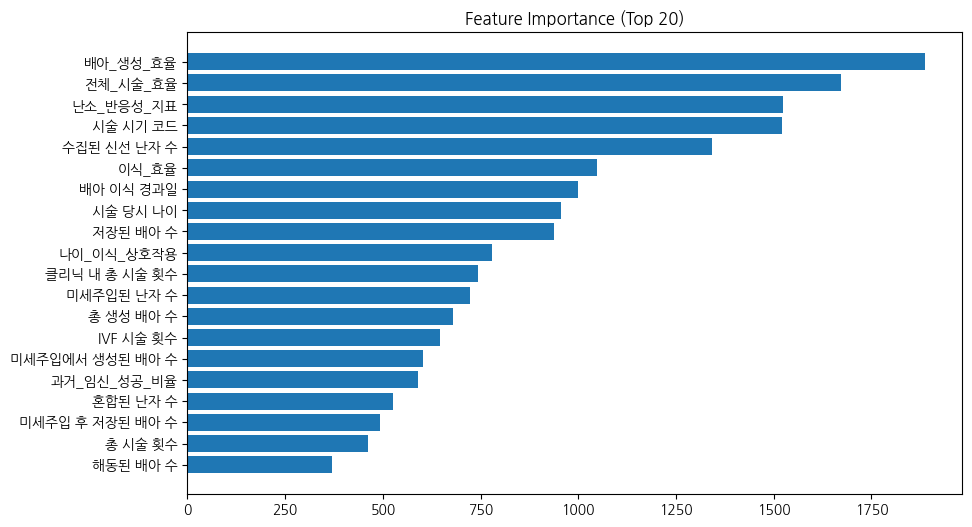

In [18]:
best_model = lgb.LGBMClassifier(**study.best_params)
best_model.fit(X, y)

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(20))

plt.figure(figsize=(10,6))
plt.barh(feat_imp["feature"].head(20), feat_imp["importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Feature Importance (Top 20)")
plt.show()

## Feature Selection + 성능 검증

In [19]:
# ======================================
# 9. Feature Selection
# ======================================
threshold = feat_imp["importance"].quantile(0.2)

low_features = feat_imp[feat_imp["importance"] < threshold]["feature"].tolist()

print(f"제거 feature 수: {len(low_features)}")

X_reduced = X.drop(columns=low_features)
test_reduced = test_df.drop(columns=low_features)


# 🔥 Feature Selection 후 CV 다시 측정 (이거 꼭 해야됨)
cv_scores_reduced = []

for tr_idx, val_idx in skf.split(X_reduced, y):
    model = lgb.LGBMClassifier(**study.best_params)

    model.fit(
        X_reduced.iloc[tr_idx], y.iloc[tr_idx],
        eval_set=[(X_reduced.iloc[val_idx], y.iloc[val_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict_proba(
        X_reduced.iloc[val_idx],
        num_iteration=model.best_iteration_
    )[:, 1]

    cv_scores_reduced.append(roc_auc_score(y.iloc[val_idx], preds))

print("Reduced CV:", np.mean(cv_scores_reduced))

# 비교
print("기존 CV:", np.mean(cv_scores))
print("FS 적용 CV:", np.mean(cv_scores_reduced))

제거 feature 수: 16
Reduced CV: 0.7399395701260623
기존 CV: 0.7400782845196877
FS 적용 CV: 0.7399395701260623


## Feature Selection 여부 결정

In [20]:
if np.mean(cv_scores_reduced) >= np.mean(cv_scores):
    print("👉 Feature Selection 사용")
    X_final = X_reduced
    test_final = test_reduced
else:
    print("👉 Feature Selection 사용 안함")
    X_final = X
    test_final = test_df

👉 Feature Selection 사용 안함


## 앙상블 학습

In [21]:
# ======================================
# 모델 학습 (LGBM + CAT)
# ======================================

lgb_model = lgb.LGBMClassifier(**study.best_params)
lgb_model.fit(X_final, y)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    verbose=0
)
cat_model.fit(X_final, y)

print("✅ 모델 학습 완료")

✅ 모델 학습 완료


## 예측 및 제출 파일 생성

In [23]:
lgb_preds = lgb_model.predict_proba(test_final)[:, 1]
cat_preds = cat_model.predict_proba(test_final)[:, 1]

# 가중 평균 (optuna까지 한 lgbm을 약간 더 신뢰)
final_preds = 0.6 * lgb_preds + 0.4 * cat_preds

submission = pd.DataFrame({
    "ID": test["ID"],
    "probability": final_preds
})

submission.to_csv("submission_ensemble.csv", index=False)

print("✅ Ensemble submission 생성 완료")

✅ Ensemble submission 생성 완료
